### Data Analysis with Python
In python, we analyse data using pandas and visualize using matplotlib and seaborn

In [2]:
import pandas as pd

In [10]:
df = pd.read_excel("coffee.xlsx")
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


#### Working with date and time
We will learn how to convert date into year, month, and day. Also how to break the time into morning, afternoon, and evening

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[ns]
 1   datetime     3636 non-null   datetime64[ns]
 2   cash_type    3636 non-null   object        
 3   card         3547 non-null   object        
 4   money        3636 non-null   float64       
 5   coffee_name  3636 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(3)
memory usage: 170.6+ KB


In [31]:
# df["date"] = pd.to_datetime(df["date"], error="coerce")

In [11]:
df["year"] = df["date"].dt.year
df.head()

,date,datetime,cash_type,card,money,coffee_name,year
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,2024
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,2024
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,2024


In [12]:
df["month"] = df["date"].dt.month_name()
df["day"] = df["date"].dt.day_name()
df.head()

,date,datetime,cash_type,card,money,coffee_name,year,month,day
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,2024,March,Friday
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024,March,Friday
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024,March,Friday
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,2024,March,Friday
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,2024,March,Friday


In [7]:
def time_check(time):
    if time.hour < 12:
        return "Morning"
    elif time.hour < 16:
        return "Afternoon"
    else:
        return "Evening"

In [13]:
df["time_of_day"] = df["datetime"].apply(time_check)
df.head()

,date,datetime,cash_type,card,money,coffee_name,year,month,day,time_of_day
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,2024,March,Friday,Morning
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024,March,Friday,Afternoon
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024,March,Friday,Afternoon
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,2024,March,Friday,Afternoon
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,2024,March,Friday,Afternoon


In [9]:
# How to drop/select columns
# To select multiple columns
df = df[["month", "year", "day"]]
df.head()

,month,year,day
0,March,2024,Friday
1,March,2024,Friday
2,March,2024,Friday
3,March,2024,Friday
4,March,2024,Friday


In [14]:
# To drop columns you don't want
df = df.drop(["date", "datetime", "card"], axis=1)
df.head()

,cash_type,money,coffee_name,year,month,day,time_of_day
0,card,38.7,Latte,2024,March,Friday,Morning
1,card,38.7,Hot Chocolate,2024,March,Friday,Afternoon
2,card,38.7,Hot Chocolate,2024,March,Friday,Afternoon
3,card,28.9,Americano,2024,March,Friday,Afternoon
4,card,38.7,Latte,2024,March,Friday,Afternoon


In [15]:
# Data Summary 
# In python we use the groupby function for data summary. It also uses the aggregation functions
monthly_revenue = df.groupby("month")["money"].sum()
monthly_revenue

month
April         6720.56
August        7613.84
December      8237.74
February     13215.48
January       6398.86
July          6915.94
June          7758.76
March        17036.64
May           9063.42
November      8590.54
October      13891.16
September     9988.64
Name: money, dtype: float64

In [16]:
daily_sales = df.groupby("day")["day"].count()
daily_sales

day
Friday       544
Monday       561
Saturday     482
Sunday       434
Thursday     520
Tuesday      585
Wednesday    510
Name: day, dtype: int64

In [17]:
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
# Chart for Monthly Revenue
monthly_revenue.plot(kind="line", color="green", marker="o")
plt.title("Revenue per Month")
plt.ylabel("Total Revenue")
plt.show()

In [ ]:
coffee_revenue = df.groupby("coffee_name")["money"].sum()
coffee_revenue

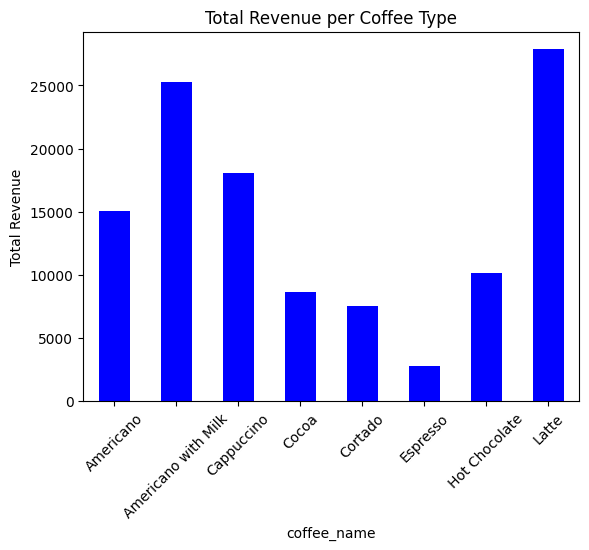

In [24]:
coffee_revenue.plot(kind="bar", color="blue")
plt.ylabel("Total Revenue")
plt.title("Total Revenue per Coffee Type")
plt.xticks(rotation=45)
plt.show()